In [221]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import pandas as pd
import numpy as np
import warnings
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
nltk.download('punkt_tab')

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/jupyter-238502/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

We wish to determine whether a given email is spam, unimportant and unwanted, or ham, something that the recipient actually cares about, using its contents. We will train a model on an archive of emails whose status as spam or ham is already known in order to solve this problem.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

We were provided a folder containing each email in the training set in a separate text file, with the spam emails being indicated as such via the name of the text files. When we actually use this data, we will later load it into a dataframe.

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

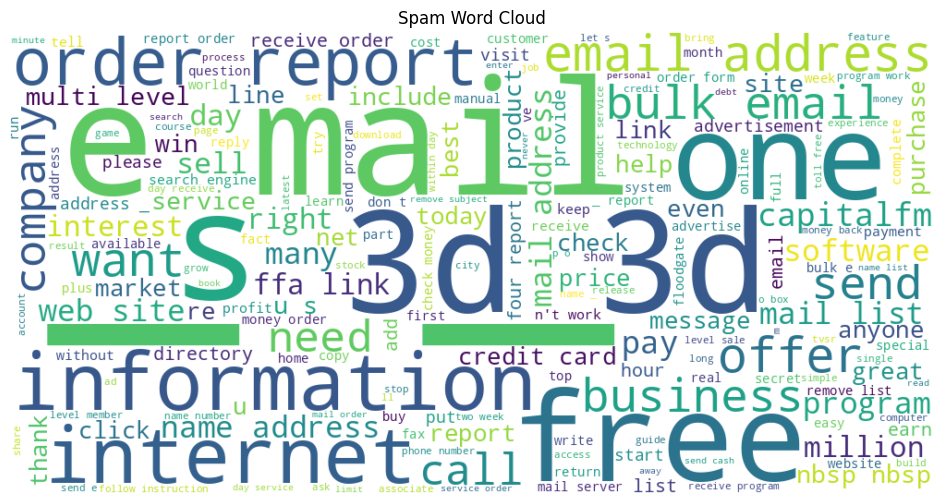

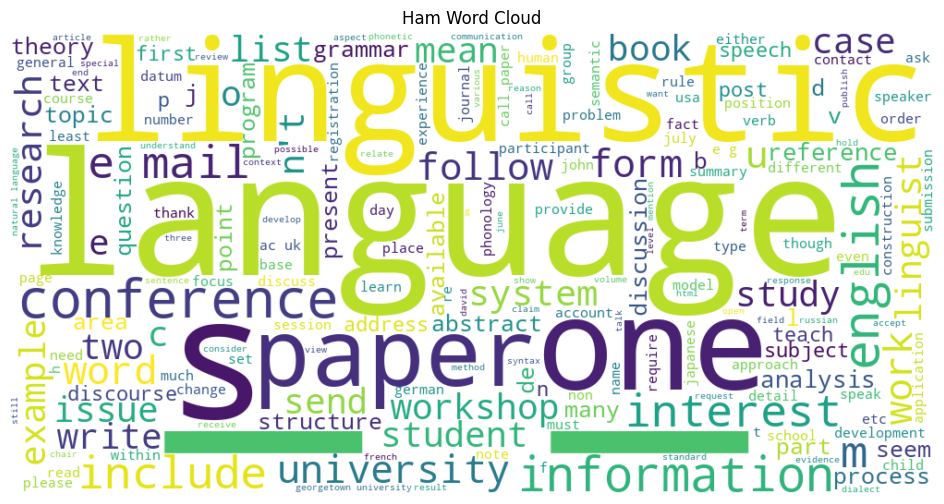

In [200]:
df = pd.DataFrame(columns=['Text', 'Spam'])
for email in os.listdir('email_archive'):
    if len(email) >= 4 and email[-4:] == '.txt':
        with open(os.path.join('email_archive', email)) as f:
            df.loc[len(df)] = [f.read(), email[:3] == 'spm']
    # Load the data to a dataframe

spam_text = ' '.join(df[df['Spam']]['Text'].astype(str))
ham_text = ' '.join(df[~df['Spam']]['Text'].astype(str))
spam_text = spam_text.replace('Subject: ', '')
ham_text = ham_text.replace('Subject: ', '')
    # Create one aggregated string out of both the spam and ham emails

wordcloud_spam = WordCloud(width=1000, height=500, background_color='white').generate(spam_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()
wordcloud_ham = WordCloud(width=1000, height=500, background_color='white').generate(ham_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()
    # Create and display word clouds

Initially, I was biased to believe that spam and ham emails would be difficult to distinguish based on basic features alone, seeing as spam emails would likely be designed to not be obviously spam. However, creating the word clouds showed that the most common words in both emails were noticably different. Common words in spam emails adhering to a common theme include "free", "order", "business", and "offer", whereas some examples from the ham emails include "language", "information", "conference", and "paper". These trends suggest that we may want to utilize a tool that can look at the individual words within an email, such as a tokenizer.

More trends we noticed just by opening some of the emails manually is that spam emails tend to be longer than ham emails, and also that ham emails tend to have unusual patterns of special characters. The former suggests creating an attribute for message length, and the latter suggets that it may be helpful to try to measure the use of special characters through some attribute.

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [201]:
df = pd.DataFrame(columns=['Text', 'Spam'])
for email in os.listdir('email_archive'):
    if len(email) >= 4 and email[-4:] == '.txt':
        with open(os.path.join('email_archive', email)) as f:
            df.loc[len(df)] = [f.read(), email[:3] == 'spm']
df['Subject'] = df['Text'].apply(lambda text: text.split('\n')[0][len('Subject: '):])
df['Body'] = df['Text'].apply(lambda text: text.split('\n')[2])
df.drop('Text', axis=1, inplace=True)
    # Separate subject from body

df['SubjectLength'] = df['Subject'].apply(len)
df['BodyLength'] = df['Body'].apply(len)
    # Create attributes for length

df['SubjectTokens'] = df['Subject'].apply(word_tokenize)
df['BodyTokens'] = df['Body'].apply(word_tokenize)
df['BodyTokens'] = df['BodyTokens'].apply(lambda tokens: [token.lower() for token in tokens if token.isalpha()])
df['TokenCounts'] = df['BodyTokens'].apply(Counter)
    # Tokenize body of emails

df['SpecialCharacters'] = df.apply(lambda email: sum([email['Body'].count(symbol) for symbol in ['_', '-', '=', '*', '!', '.', '$', '/', '+']]) / email['BodyLength'], axis=1)
    # Count proportion of each email taken by special characters

In [202]:
df.reset_index(drop=True, inplace=True)
df['ID'] = range(len(df))
X = df[df.columns[1:]]
y = df['Spam']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
    # Define the training and testing datasets

vocabulary = X_train['TokenCounts'].sum()
words_descending = sorted(vocabulary.keys(), key=vocabulary.get, reverse=True)
most_common = 100
for word in words_descending[:most_common]:
    df[word] = df['TokenCounts'].apply(lambda tokens: tokens.get(word, 0))
    # Add word counts for 100 most common words based on tokenization

df.drop(['Subject', 'Body', 'SubjectTokens', 'BodyTokens', 'TokenCounts', 'ID'], axis=1, inplace=True)
X_train = df.loc[X_train['ID']]
X_test = df.loc[X_test['ID']]
X_train.drop('Spam', axis=1, inplace=True)
X_test.drop('Spam', axis=1, inplace=True)
print(X_train.columns)
    # Redefine X sets based on changes to dataframe and
    # Drop non-numerical columns
print(df.head(5))

Index(['SubjectLength', 'BodyLength', 'SpecialCharacters', 'language',
       'report', 'order', 'address', 'mail', 'university', 'send',
       ...
       'place', 'home', 'question', 'phone', 'after', 'pay', 'where',
       'provide', 'contact', 'o'],
      dtype='object', length=103)
    Spam  SubjectLength  BodyLength  SpecialCharacters  language  report  \
0  False             46        1917           0.027126         0       0   
1  False             35        1339           0.015683         1       0   
2  False             31         953           0.144806         7       0   
3   True             14         311           0.041801         0       0   
4  False             16        1218           0.022989         2       0   

   order  address  mail  university  ...  place  home  question  phone  after  \
0      0        0     0           0  ...      1     1         1      0      1   
1      0        1     0           0  ...      0     0         0      0      0   
2      0    

After loading all of our email data into a dataframe, since all emails have a clear subject and body we separate these into two separate attributes. Since we already noted that length would be important, we created attributes for the length of both the subject and body of the email. Finally, we tokenized the content of the emails so that when we model the data we have easy to work with tokens. We grabbed the 100 most common words based on the training data, and then created new features for how many times each of these occur in the body of the emails.

We note that while preparing the data, we should probably try to manually extract features that we think will be helpful (like body length) even if they are available through other features, because it may be hard for the model to extract this data on its own for text based data in particular. Notably, by this point we have already extracted numerical features from the email and have dropped the text entirely.

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [226]:
    # Model using Random Forest
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print(accuracy)

0.9587155963302753


In [224]:
scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)
model_knn = KNeighborsClassifier(n_neighbors=20)
model_knn.fit(X_train_normalized, y_train)
y_pred_knn = model_knn.predict(X_test_normalized)
accuracy = accuracy_score(y_test, y_pred_knn)
print(accuracy)

0.8486238532110092


In [225]:
    # Model using Gaussian Naive Bayes
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)
y_pred_gnb = model_gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_gnb)
print(accuracy)

0.7568807339449541


Given the easily discernible patterns in the word clouds, we expected our tokenization to produce strong results. We tried three models: Random Forest, KNN, and Gaussian Naive Bayes. We expected Random Forest to perform strongly for this project because it has been successful in the past and we already gave it easy to use numerical features. It indeed produced a high accuracy of 95.87%. The other two models produced accuracies of 84.9% and 75.7% respectively. Therefore, we decided to move forward with tuning our random forest model.

# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


0.5059760956175299


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


Not Purchase
